# Data Exploration

In [1]:
import os

BASE_DATA_DIR = "/teamspace/studios/this_studio/sound_datasets/urbansound8k"
AUDIO_DIR = os.path.join(BASE_DATA_DIR, "audio")
METADATA_FILE = os.path.join(BASE_DATA_DIR, "metadata", "UrbanSound8K.csv")

In [2]:
import pandas as pd

metadata_df = pd.read_csv(METADATA_FILE)
metadata_df.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [3]:
# examine the class distribution
metadata_df["class"].value_counts()

class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
engine_idling       1000
jackhammer          1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64

## Mel Spectogram Representation

In [4]:
import torch
import torchaudio
import torchaudio.functional as F
import torchaudio.transforms as T

torch.random.manual_seed(0)

SAMPLE_AUDIO_IDX = 784
SAMPLE_AUDIO = os.path.join(AUDIO_DIR, f"fold{metadata_df.iloc[SAMPLE_AUDIO_IDX, 5]}", metadata_df.iloc[SAMPLE_AUDIO_IDX, 0])
print(f"Sample audio class: {metadata_df.iloc[SAMPLE_AUDIO_IDX, 7]}")
SAMPLE_AUDIO

Sample audio class: street_music


'/teamspace/studios/this_studio/sound_datasets/urbansound8k/audio/fold10/115241-9-0-6.wav'

In [5]:
import matplotlib.pyplot as plt
from IPython.display import Audio

def plot_waveform(waveform, sr, title="Waveform", ax=None):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sr

    if ax is None:
        _, ax = plt.subplots(num_channels, 1)
    ax.plot(time_axis, waveform[0], linewidth=1)
    ax.grid(True)
    ax.set_xlim([0, time_axis[-1]])
    ax.set_title(title)


def plot_spectrogram(specgram, title=None, ylabel="freq_bin", ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    if title is not None:
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    power_to_db = T.AmplitudeToDB("power", 80.0)
    ax.imshow(power_to_db(specgram), origin="lower", aspect="auto", interpolation="nearest")


def plot_fbank(fbank, title=None):
    fig, axs = plt.subplots(1, 1)
    axs.set_title(title or "Filter bank")
    axs.imshow(fbank, aspect="auto")
    axs.set_ylabel("frequency bin")
    axs.set_xlabel("mel bin")

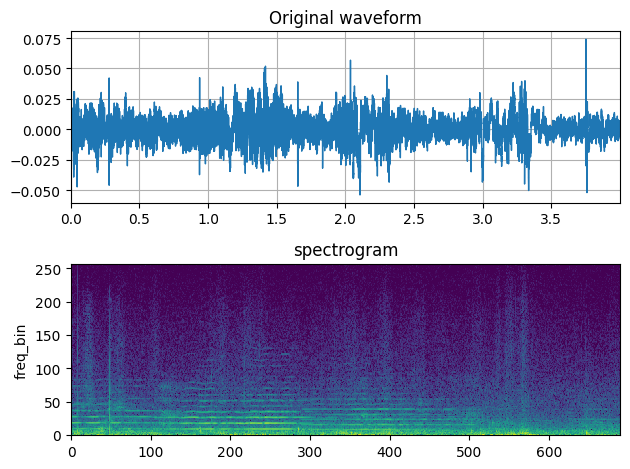

In [6]:
AUDIO_WAVEFORM, SAMPLE_RATE = torchaudio.load(SAMPLE_AUDIO)
spectrogram = T.Spectrogram(n_fft=512)
spec = spectrogram(AUDIO_WAVEFORM)

fig, axs = plt.subplots(2, 1)
plot_waveform(AUDIO_WAVEFORM, SAMPLE_RATE, title="Original waveform", ax=axs[0])
plot_spectrogram(spec[0], title="spectrogram", ax=axs[1])
fig.tight_layout()

In [7]:
Audio(AUDIO_WAVEFORM.numpy(), rate=SAMPLE_RATE)

/teamspace/studios/this_studio/urbansound/.venv/lib/python3.13/site-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


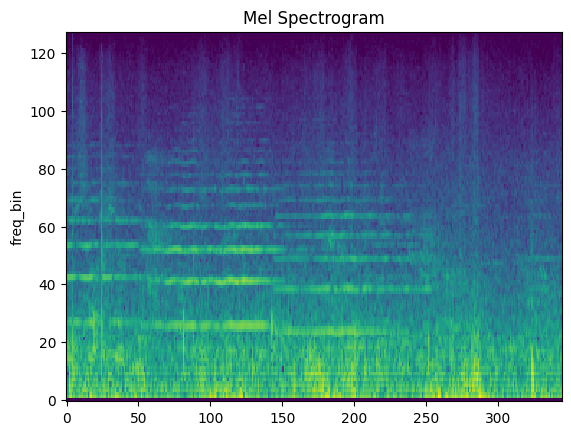

In [8]:
n_fft = 1024
win_length = None
hop_length = 512
n_mels = 128

mel_spectrogram = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=n_fft,
    win_length=win_length,
    hop_length=hop_length,
    center=True,
    pad_mode="reflect",
    power=2.0,
    norm="slaney",
    n_mels=n_mels,
    mel_scale="htk",
)

melspec = mel_spectrogram(AUDIO_WAVEFORM)

plot_spectrogram(melspec[0], title="Mel Spectrogram", ax=None)

/teamspace/studios/this_studio/urbansound/.venv/lib/python3.13/site-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (256) may be set too high. Or, the value for `n_freqs` (1025) may be set too low.
  warnings.warn(


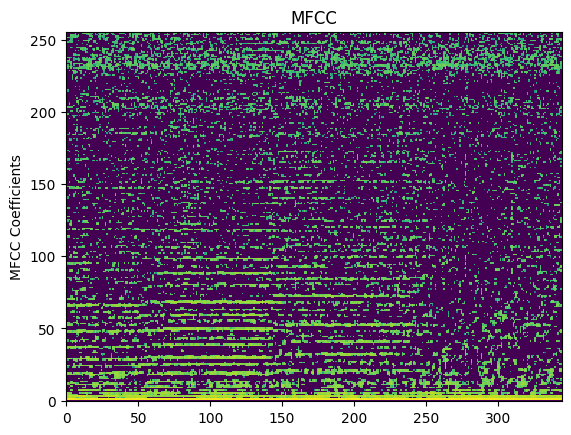

In [9]:
n_fft = 2048
win_length = None
hop_length = 512
n_mels = 256
n_mfcc = 256

mfcc_transform = T.MFCC(
    sample_rate=SAMPLE_RATE,
    n_mfcc=n_mfcc,
    melkwargs={
        "n_fft": n_fft,
        "n_mels": n_mels,
        "hop_length": hop_length,
        "mel_scale": "htk",
    },
)

mfcc = mfcc_transform(AUDIO_WAVEFORM)

plot_spectrogram(mfcc[0], title="MFCC", ylabel="MFCC Coefficients", ax=None)

## Temporal Sparsity (The "Silence" Problem)

Gun shot audio: /teamspace/studios/this_studio/sound_datasets/urbansound8k/audio/fold8/131571-6-0-0.wav


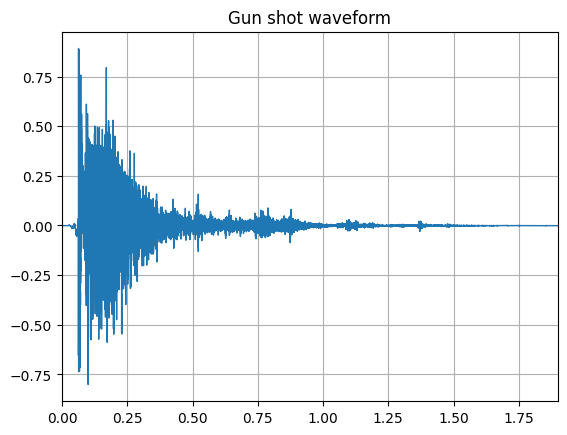

In [14]:
gun_shot_idx = metadata_df[metadata_df["class"] == "gun_shot"].index[5]
gun_shot_audio = os.path.join(AUDIO_DIR, f"fold{metadata_df.iloc[gun_shot_idx, 5]}", metadata_df.iloc[gun_shot_idx, 0])
print(f"Gun shot audio: {gun_shot_audio}")

gun_shot_waveform, gun_shot_sr = torchaudio.load(gun_shot_audio)

fig, ax = plt.subplots(1, 1)
plot_waveform(gun_shot_waveform, gun_shot_sr, title="Gun shot waveform", ax=ax)
Audio(gun_shot_waveform.numpy(), rate=gun_shot_sr)

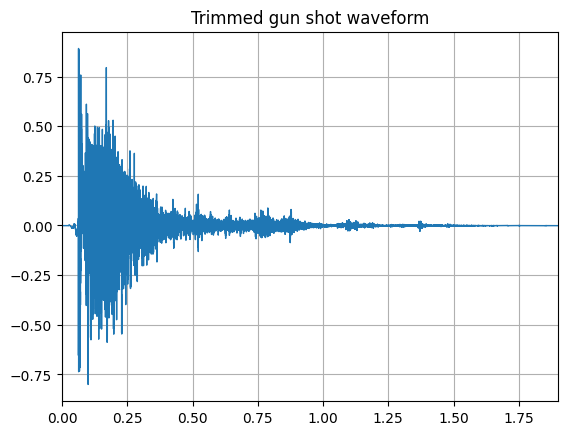

In [15]:
import librosa

gun_shot_t, index = librosa.effects.trim(gun_shot_waveform.numpy()[0])

plot_waveform(torch.from_numpy(gun_shot_t).unsqueeze(0), gun_shot_sr, title="Trimmed gun shot waveform", ax=None)
Audio(gun_shot_t, rate=gun_shot_sr)